## 1. Visão Geral dos Dados

Nesta etapa, o objetivo é compreender a estrutura do conjunto de dados antes de qualquer tratamento: quais colunas cada tabela possui, como elas se conectam entre si, e um primeiro diagnóstico de qualidade (tipos de dados, valores ausentes e volume de linhas).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df_events = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projeto mate/events.csv')
df_countries = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projeto mate/countries.csv')
df_products =  pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projeto mate/products.csv')




Mounted at /content/drive


Foram importadas as bibliotecas essenciais para manipulação de dados (`pandas`, `numpy`) e visualização (`matplotlib`, `seaborn`). Os arquivos foram acessados via Google Drive, garantindo que o notebook possa ser reaberto e reexecutado sem necessidade de novo upload manual a cada sessão.


O conjunto de dados é composto por três tabelas com granularidades distintas:
- **`events`**: registros de pedidos de venda (nível de transação individual);
- **`products`**: catálogo de categorias de produto;
- **`countries`**: catálogo de países, com região e sub-região.

Optei por carregar as três tabelas separadamente, mantendo-as isoladas até a etapa de limpeza. Essa abordagem evita que problemas de qualidade em uma tabela se propaguem para as outras antes de serem tratados, e só faz sentido uni-las após a limpeza individual de cada uma.

In [3]:
df_events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [4]:
df_countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [5]:
df_products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


Uma inspeção inicial das primeiras linhas de cada tabela confirma o formato esperado das colunas. Identifiquei os campos-chave que conectam as três tabelas:
- `Product ID` (em `events`) - `id` (em `products`);
- `Country Code` (em `events`) - `alpha-3` (em `countries`) — confirmado por comparação direta entre os valores.

In [6]:
# rodando info para análise inicial
df_events.info()
df_countries.info()
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-

A análise de `.info()` nas três tabelas revelou os seguintes pontos de atenção, que serão tratados na etapa de limpeza:

- **`events`**: as colunas `Order Date` e `Ship Date` estão como tipo `object` (texto), quando deveriam ser do tipo data — necessário conversão. As colunas `Country Code` e `Units Sold` apresentam valores ausentes.
- **`countries`**: as colunas `alpha-2`, `region` e `sub-region` apresentam 1 valor ausente cada.
- **`products`**: 12 categorias de produto, sem inconsistências aparentes nesta primeira inspeção.




## 2. Limpeza dos Dados

Nesta etapa, tratamos os problemas de qualidade identificados na visão geral: valores ausentes, tipos de dados incorretos, duplicatas e possíveis anomalias. Cada decisão de tratamento é justificada com base na causa raiz identificada, e não aplicada de forma genérica — priorizando preservar informação válida sempre que a ausência não comprometer a integridade da análise.

In [7]:
#verificação das linhas nulas em df_countries nas colunas alpha-2, region e sub-region
df_countries.isnull().sum()
df_countries[df_countries.isnull().any(axis=1)]


,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [8]:
#verificação de linhas nulas em df_events
df_events.isnull().sum()


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


Verifiquei a presença de valores ausentes em cada tabela usando `isnull().sum()`, e isolamos as linhas afetadas para investigação da causa. Em `countries`, identifiquei que as colunas `alpha-2`, `region` e `sub-region` apresentam 1 valor ausente — e as três ausências pertencem à mesma linha, o que já sugere que se trata de um único registro problemático, não de três ocorrências isoladas. Em `events`, identificamos 82 valores ausentes em `Country Code` e 2 em `Units Sold`.

In [9]:
#verificação de quais as strings estão presentes em df_events, coluna country code,
df_events['Country Code'].value_counts(dropna=False)


,count
Country Code,
NaN,82
SMR,40
AND,40
ROU,34
UKR,33
BIH,33
RUS,32
MLT,32
GRC,32


Ao investigar a linha ausente em `countries`, identifiquei que se tratava do país **Namibia**. A causa raiz é que o código alpha-2 de Namibia é literalmente a string `"NA"`, que o pandas reconhece por padrão como marcador de valor ausente ao importar o CSV — ou seja, não é um dado realmente faltante, mas um falso nulo causado por uma coincidência entre o código do país e a convenção do pandas.

Investiguei se esse mesmo problema afetaria a coluna `Country Code` em `events`, já que ela usa o padrão alpha-3 (3 letras) em vez de alpha-2. Como o alpha-3 de Namibia é `"NAM"` — string que não está na lista de nulos padrão do pandas — confirmei que os 82 valores ausentes em `events` são um problema distinto, não relacionado ao caso de Namibia. Uma checagem adicional confirmou que Namibia simplesmente não possui pedidos registrados na tabela `events` no período coberto pelo dataset, o que é esperado dado que `countries` é uma lista de referência com praticamente todos os países do mundo, enquanto `events` reflete apenas os países onde houve transação.

In [10]:
#criando função para analisar possível padrão em valores nulos
nulos_country = df_events[df_events['Country Code'].isnull()]
nulos_country.shape

(82, 10)

In [11]:
nulos_country['Sales Channel'].value_counts()

,count
Sales Channel,
Offline,44
Online,38


In [12]:
nulos_country['Order Priority'].value_counts()


,count
Order Priority,
M,23
L,21
H,19
C,19


In [13]:
nulos_country['Order Date'].str[-4:].value_counts()

,count
Order Date,
2012,15
2014,14
2011,12
2015,10
2016,10
2013,8
2010,7
2017,6


In [14]:
nulos_country['Product ID'].value_counts()

,count
Product ID,
8681,10
4594,9
5988,9
8969,8
1270,8
8875,8
7331,7
7940,6
3127,6


Para decidir o tratamento mais adequado para os 82 valores ausentes de `Country Code`, investiguei se havia algum padrão sistemático associado a essas linhas, isolando-as em um DataFrame separado (`nulos_country`) e analisando sua distribuição em relação a outras variáveis:

- **Canal de venda** (`Sales Channel`): distribuição próxima da proporção geral da tabela, sem concentração relevante em Online ou Offline.
- **Prioridade do pedido** (`Order Priority`): distribuição também equilibrada entre as categorias, sem indício de relação.
- **Ano do pedido** (extraído de `Order Date`): observei uma leve concentração em 2012 e 2014, mas os nulos aparecem espalhados por outros anos também — não é suficiente para caracterizar uma causa sazonal ou pontual.
- **Produto** (`Product ID`): três produtos se destacaram com até 10 ocorrências nulas cada, mas o restante está distribuído entre outras categorias, sem uma concentração dominante.

Concluí que a ausência de `Country Code` não está associada a nenhuma causa sistemática identificável — nem canal, nem prioridade, nem produto, nem período isolam o problema de forma clara. Diante disso, optei por não excluir essas linhas (o que descartaria informações válidas de produto, unidades vendidas e receita) e, em vez disso, preencher os valores ausentes com o marcador `"Unknown"`, deixando explícito que o país não pôde ser identificado sem inventar um valor.

In [15]:
nulos_units = df_events[df_events['Units Sold'].isnull()]
nulos_units[['Order ID', 'Country Code']]

,Order ID,Country Code
183,217165648,ESP
319,309655511,HRV


In [16]:
df_events[df_events['Units Sold'].isnull()]


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67


Investiguei as 2 linhas com valores ausentes em `Units Sold`, analisando todas as colunas para entender o contexto de cada registro. Diferente do caso de `Country Code`, aqui não considerei viável preencher o valor ausente: `Units Sold` é uma variável numérica que alimenta diretamente o cálculo de receita e lucro, e uma adição (como uma mediana geral) introduziria valores fabricados nas métricas financeiras do relatório, distorcendo a análise. Como o impacto de excluir apenas 2 registros de aproximadamente 1330 é estatisticamente irrelevante, optei por remover essas linhas, priorizando a integridade dos cálculos financeiros sobre a preservação de dados que não podem ser confiavelmente estimados.

In [17]:
#duplicatas em product
df_products['item_type'].str.strip().str.lower().duplicated().sum()

np.int64(0)

In [18]:
#duplicatas em countries
df_countries['name'].str.strip().str.lower().duplicated().sum()
df_countries['alpha-3'].str.strip().str.lower().duplicated().sum()

np.int64(0)

In [19]:
df_events['Order ID'].duplicated().sum()

np.int64(0)

In [20]:
df_events.duplicated().sum()

np.int64(0)

Investiguei a existência de duplicatas nas três tabelas, considerando não apenas duplicatas exatas, mas também casos "camuflados" por espaços extras ou diferença de maiúsculas/minúsculas, normalizando as colunas de texto antes da comparação.

Em `products` e `countries`, não identifiquei nenhuma duplicata — nem na comparação direta, nem após normalizar as colunas de texto (`item_type`, `name` e os códigos de país). Em `events`, verifiquei especificamente a coluna `Order ID` (chave primária da tabela, que deveria ser única por definição) e também a linha completa, e não encontrei nenhuma ocorrência duplicada em nenhuma das duas checagens.

Concluí que o conjunto de dados não apresenta problemas de duplicação, e essa etapa não exigiu nenhuma transformação adicional.

###2.1 Investigação de Anomalias

Além de valores ausentes e duplicatas, investiguei a existência de anomalias nos dados — valores que são tecnicamente válidos no formato, mas inconsistentes ou improváveis do ponto de vista de negócio. Utilizei o `describe()` como ponto de partida para identificar variáveis numéricas com amplitude ou distribuição suspeita, e o `unique()` para revisar a consistência de variáveis categóricas.

In [21]:
#resultados gerais de events
df_events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [22]:
#valores unicos em sales channel
df_events['Sales Channel'].unique()

array(['Online', 'Offline', 'online'], dtype=object)

In [23]:
#valores únicos em order priority
df_events['Order Priority'].unique()

array(['M', 'C', 'L', 'H', ' C', 'M '], dtype=object)

Ao verificar os valores únicos das colunas categóricas, identifiquei inconsistências de formatação em ambas:

- **`Sales Channel`**: os valores `'Online'`, `'Offline'` e `'online'` representam apenas duas categorias reais, mas a diferença de capitalização faz o pandas tratá-las como três valores distintos.
- **`Order Priority`**: os valores `'M'`, `'C'`, `'L'`, `'H'`, `' C'` e `'M '` representam apenas quatro níveis de prioridade, mas espaços extras em `' C'` e `'M '` fazem com que sejam contados separadamente das versões sem espaço.

Ambos os casos serão corrigidos na consolidação da limpeza, padronizando o texto (removendo espaços e uniformizando capitalização).

In [24]:
df_events[df_events['Unit Cost'] > df_events['Unit Price']]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [25]:
df_events[(df_events['Unit Price'] <= 0) | (df_events['Unit Cost'] <= 0)]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


Investiguei também possíveis anomalias de valor nas colunas financeiras, verificando se existiam pedidos com `Unit Cost` maior que `Unit Price` (o que indicaria venda com prejuízo) e se havia valores zerados ou negativos em `Unit Price` ou `Unit Cost` (o que seria logicamente inválido para essas colunas). Nenhuma das duas verificações retornou resultados, confirmando que os valores financeiros do dataset são consistentes.

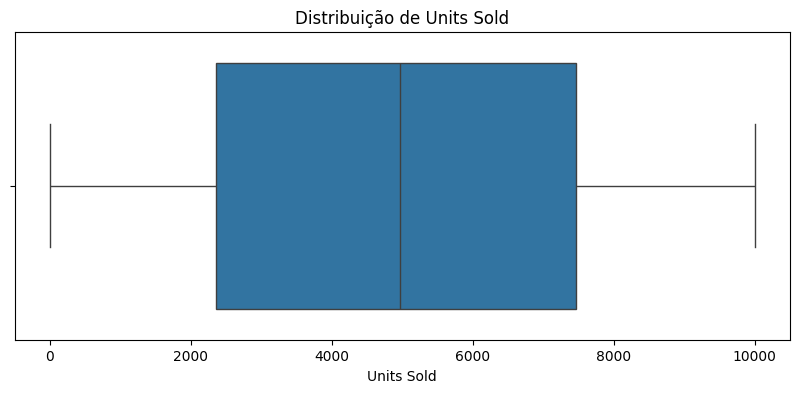

In [26]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_events['Units Sold'])
plt.title('Distribuição de Units Sold')
plt.show()

In [27]:
order_date_temp = pd.to_datetime(df_events['Order Date'])
ship_date_temp = pd.to_datetime(df_events['Ship Date'])

df_events[ship_date_temp < order_date_temp]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


Para investigar se o valor máximo de `Units Sold` (9999) representava um outlier, visualizei a distribuição da coluna com um boxplot. A caixa (entre os quartis 25% e 75%) ficou consistente com o `describe()` calculado anteriormente, e os valores extremos — incluindo o máximo — permaneceram dentro da faixa considerada esperada pelo boxplot, sem nenhum ponto marcado como outlier. Concluí que a ampla variação em `Units Sold` reflete a diversidade natural de pedidos do negócio (desde pedidos pequenos até grandes volumes), e não um erro de dado.

Também verifiquei, convertendo temporariamente `Order Date` e `Ship Date` para o tipo data, se havia algum pedido com data de envio anterior à data do pedido — o que seria logicamente impossível. Não encontrei nenhuma ocorrência, confirmando a consistência temporal dos registros.

Com essas verificações, encerro a investigação de anomalias: não foram encontrados problemas de valor nas colunas financeiras, na quantidade vendida ou na consistência entre as datas.

### 2.2 Ajustes Finais de Limpeza do Dataset

Após investigar valores ausentes, tipos de dados, duplicatas e anomalias, apliquei nesta seção todas as correções decididas ao longo da Etapa 2, em um único bloco consolidado:

1. Correção do valor de `alpha-2` para o país Namibia em `df_countries` (falso nulo causado pela convenção do pandas);
2. Remoção das 2 linhas com `Units Sold` ausente em `df_events`;
3. Preenchimento dos 82 valores ausentes em `Country Code` com o marcador `"Unknown"`;
4. Conversão de `Order Date` e `Ship Date` para o tipo data;
5. Conversão de `Units Sold` para número inteiro;
6. Padronização de `Sales Channel` e `Order Priority`, corrigindo inconsistências de capitalização e espaços extras.

In [28]:
# 1. Corrige o falso nulo de Namibia em df_countries
df_countries.loc[df_countries['name'] == 'Namibia', 'alpha-2'] = 'NA'

# 2. Remove as 2 linhas com Units Sold ausente
df_events = df_events.dropna(subset=['Units Sold'])

# 3. Preenche os 82 valores ausentes de Country Code com "Unknown"
df_events['Country Code'] = df_events['Country Code'].fillna('Unknown')

# 4. Converte Order Date e Ship Date de texto (object) para o tipo datetime
df_events['Order Date'] = pd.to_datetime(df_events['Order Date'])
df_events['Ship Date'] = pd.to_datetime(df_events['Ship Date'])

# 5. Converte Units Sold para inteiro
df_events['Units Sold'] = df_events['Units Sold'].astype(int)

# 6. Padroniza Sales Channel: remove espaços extras e uniformiza
df_events['Sales Channel'] = df_events['Sales Channel'].str.strip().str.capitalize()

# 6. Padroniza Order Priority: remove espaços extras
df_events['Order Priority'] = df_events['Order Priority'].str.strip()

In [29]:
df_events.info()
print(df_events['Sales Channel'].unique())
print(df_events['Order Priority'].unique())
print(df_countries[df_countries['name'] == 'Namibia'])

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   int64         
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 114.1+ KB
['Online' 'Offline']
['M' 'C' 'L' 'H']
        name alpha-2 alpha-3  region          sub-region
153  Namibia      NA     NAM  Africa  Sub-Saharan Africa


Apliquei todas as correções decididas na etapa de limpeza e validei o resultado: a tabela `events` ficou com 1328 registros (reflexo da remoção das 2 linhas sem `Units Sold`), os tipos de dado das colunas `Order Date`, `Ship Date` e `Units Sold` foram corrigidos, `Sales Channel` e `Order Priority` passaram a ter apenas os valores válidos e padronizados, e a linha de Namibia em `countries` foi corrigida. Com isso, encerro a Etapa 2 de limpeza dos dados.

### 2.2 União das Tabelas

Com os dados devidamente limpos, uni as três tabelas em um único DataFrame (`df_final`), utilizando `Product ID` e `Country Code` como chaves de junção com `products` e `countries`, respectivamente. Optei por `LEFT JOIN` (`how='left'`) em ambos os merges, garantindo que nenhuma linha de `events` fosse perdida — inclusive os 82 registros com `Country Code = "Unknown"`, que não possuem correspondência em `countries` e, portanto, ficam com valores nulos nas colunas geográficas (região e sub-região).

Validei o resultado conferindo que o número de linhas se manteve em 1328 (o mesmo de `events` após a limpeza, sem duplicação causada pelo merge) e que os registros "Unknown" de fato ficaram com as colunas de país como nulas, como esperado.

In [30]:

df_final = df_events.merge(df_products, how='left', left_on='Product ID', right_on='id')
df_final = df_final.merge(df_countries, how='left', left_on='Country Code', right_on='alpha-3')
df_final

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92,4594,Fruits,Sweden,SE,SWE,Europe,Northern Europe
1324,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79,1270,Beverages,Italy,IT,ITA,Europe,Southern Europe
1325,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,7331,Baby Food,Russia,RU,RUS,Europe,Eastern Europe
1326,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33,8293,Cosmetics,Malta,MT,MLT,Europe,Southern Europe


In [31]:
df_final[df_final['Country Code'] == 'Unknown'][['Country Code', 'name', 'region', 'sub-region','Units Sold']]

,Country Code,name,region,sub-region,Units Sold
2,Unknown,NaN,NaN,NaN,4693
13,Unknown,NaN,NaN,NaN,7076
26,Unknown,NaN,NaN,NaN,6813
29,Unknown,NaN,NaN,NaN,2013
43,Unknown,NaN,NaN,NaN,5762
...,...,...,...,...,...
1211,Unknown,NaN,NaN,NaN,4219
1218,Unknown,NaN,NaN,NaN,6134
1248,Unknown,NaN,NaN,NaN,9917
1294,Unknown,NaN,NaN,NaN,6893


In [32]:
df_final['name'] = df_final['name'].fillna('Unknown')
df_final = df_final.drop(columns=['id', 'alpha-2', 'alpha-3', 'Country Code'])
df_final.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Product ID',
       'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost', 'item_type',
       'name', 'region', 'sub-region'],
      dtype='object')

Removi as colunas `id` e `alpha-3`, redundantes com `Product ID` e `Country Code` (traziam a mesma informação vinda da tabela de origem). Antes de remover `Country Code`, transferi a marcação `"Unknown"` (usada na limpeza para os 82 registros sem país identificado) para a coluna `name`, preservando essa informação de forma consistente na coluna que efetivamente será usada como referência geográfica nas análises. Também removi `alpha-2`, por não ser necessária para as análises seguintes.

In [33]:
df_final = df_final.rename(columns={
    'name': 'Country',
    'item_type': 'Product Category',
    'region': 'Region',
    'sub-region': 'Sub-Region'
})

Renomeei algumas colunas do `df_final` para melhorar a legibilidade do relatório e das visualizações: `name` para `Country` (o nome original, sozinho, não deixava claro que se tratava do país), `item_type` para `Product Category`, `region` para `Region` e `sub-region` para `Sub-Region` — mantendo o padrão de capitalização já usado nas demais colunas.

In [34]:
df_products.groupby('item_type')['id'].nunique()

,id
item_type,
Baby Food,1
Beverages,1
Cereal,1
Clothes,1
Cosmetics,1
Fruits,1
Household,1
Meat,1
Office Supplies,1


In [35]:
df_final = df_final.drop(columns=['Product ID'])
df_final.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority',
       'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost',
       'Product Category', 'Country', 'Region', 'Sub-Region'],
      dtype='object')

Antes de decidir sobre a coluna `Product ID`, investiguei se ela carregava granularidade adicional em relação a `Product Category` (`item_type`), agrupando `df_products` por categoria e contando quantos códigos de produto únicos existiam em cada uma. O resultado mostrou exatamente 1 `Product ID` por categoria em todos os casos — ou seja, cada categoria corresponde a um único código de produto, sem subdivisão. Com isso, `Product ID` não agrega informação além do que `Product Category` já representa, e removi a coluna do `df_final` para evitar redundância.

## 3. Análise e Visualização de Dados

Com o dataset limpo, unificado e as colunas de receita, custo e lucro calculadas, inicio a etapa de análise. Começo com uma visão executiva do desempenho geral da empresa, e em seguida aprofundo a análise por categoria de produto, geografia, canal de vendas e dimensão temporal.

### 3.1 Métricas-Chave de Desempenho

Antes de entrar nos detalhes por categoria, país ou canal, calculei um conjunto de métricas gerais que resumem o desempenho global da empresa no período coberto pelo dataset.

In [36]:
print(df_final)

       Order ID Order Date  Ship Date Order Priority Sales Channel  \
0     100640618 2014-10-08 2014-10-18              M        Online   
1     100983083 2016-08-11 2016-08-11              C       Offline   
2     101025998 2014-07-18 2014-08-11              M        Online   
3     102230632 2017-05-13 2017-06-13              L        Online   
4     103435266 2012-08-11 2012-09-18              H       Offline   
...         ...        ...        ...            ...           ...   
1323  994504153 2017-01-10 2017-01-13              M        Online   
1324  994978797 2014-12-05 2015-01-02              H       Offline   
1325  996754205 2010-09-20 2010-09-22              L       Offline   
1326  998043382 2010-06-15 2010-07-03              H        Online   
1327  999879729 2012-03-31 2012-05-06              M       Offline   

      Units Sold  Unit Price  Unit Cost Product Category     Country  Region  \
0            650      205.70     117.11           Cereal      Norway  Europe   

In [37]:
#adicionando coluna de receita, custo total e lucro
df_final['Revenue'] = df_final['Unit Price'] * df_final['Units Sold']
df_final['Cost'] = df_final['Unit Cost'] * df_final['Units Sold']
df_final['Profit'] = df_final['Revenue'] - df_final['Cost']

In [38]:
# Volume
total_pedidos = df_final.shape[0]
total_unidades = df_final['Units Sold'].sum()

# Financeiro
receita_total = df_final['Revenue'].sum()
custo_total = df_final['Cost'].sum()
lucro_total = df_final['Profit'].sum()
margem_lucro = (lucro_total / receita_total) * 100

# Alcance
total_paises = df_final['Country'].nunique()
total_categorias = df_final['Product Category'].nunique()

# Ticket médio
ticket_medio = receita_total / total_pedidos

# Exibindo tudo
print(f"Total de pedidos: {total_pedidos}")
print(f"Total de unidades vendidas: {total_unidades}")
print(f"Receita total: {receita_total:,.2f}")
print(f"Custo total: {custo_total:,.2f}")
print(f"Lucro total: {lucro_total:,.2f}")
print(f"Margem de lucro: {margem_lucro:.2f}%")
print(f"Total de países: {total_paises}")
print(f"Total de categorias: {total_categorias}")
print(f"Ticket médio por pedido: {ticket_medio:,.2f}")

Total de pedidos: 1328
Total de unidades vendidas: 6576524
Receita total: 1,702,129,408.21
Custo total: 1,200,694,949.21
Lucro total: 501,434,459.00
Margem de lucro: 29.46%
Total de países: 46
Total de categorias: 12
Ticket médio por pedido: 1,281,723.95


Calculei as métricas-chave de desempenho da empresa a partir do `df_final`:

- **Total de pedidos**: 1.328
- **Total de unidades vendidas**: 6.576.524
- **Receita total**: R$ 1.702.129.408,21

- **Custo total**: R$ 1.200.694.949,21

- **Lucro total**: R$ 501.434.459,00

- **Margem de lucro**: 29,46%
- **Total de países atendidos**: 46 (sendo um deles a categoria Unknown, referente a países desconhecidos)
- **Total de categorias de produto**: 12
- **Ticket médio por pedido**: R$ 1.281.723,95

O ticket médio elevado, combinado com o volume médio de unidades por pedido observado na etapa de limpeza (mediana de ~4.962 unidades), indica que o dataset reflete um perfil de vendas em grande volume — mais característico de operações atacadistas/B2B do que de venda direta ao consumidor final. A margem de lucro de aproximadamente 29% sugere uma operação financeiramente saudável no período analisado.

In [39]:
# Calculo total de receita, custo, lucro, unidades vendidas e margem por categoria
df_categoria = df_final.groupby('Product Category').agg({
    'Revenue': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).reset_index()

# Margem de lucro (%) = quanto do valor vendido virou lucro
df_categoria['Profit Margin (%)'] = (df_categoria['Profit'] / df_categoria['Revenue']) * 100
df_categoria.sort_values('Profit Margin (%)', ascending=False)

,Product Category,Revenue,Cost,Profit,Units Sold,Profit Margin (%)
3,Clothes,6.462655e+07,2.119524e+07,43431314.40,591385,67.203514
2,Cereal,9.579140e+07,5.453637e+07,41255034.15,465685,43.067574
11,Vegetables,8.974673e+07,5.297073e+07,36776002.72,582544,40.977541
4,Cosmetics,2.331548e+08,1.404315e+08,92723306.17,533291,39.768984
0,Baby Food,1.436476e+08,8.970659e+07,53940997.16,562706,37.550924
10,Snacks,7.478861e+07,4.776119e+07,27027422.40,490160,36.138419
1,Beverages,2.909316e+07,1.949150e+07,9601662.78,613133,33.003161
9,Personal Care,4.557902e+07,3.160361e+07,13975410.68,557678,30.661936
5,Fruits,5.520300e+06,4.094370e+06,1425929.52,591672,25.830654
6,Household,2.942052e+08,2.212427e+08,72962466.77,440249,24.799856


Agrupei os dados por `Product Category`, somando receita, custo, lucro e unidades vendidas, e calculei a margem de lucro percentual de cada categoria (`Profit / Revenue`).

O resultado revela uma diferença importante entre volume e rentabilidade: Office Supplies lidera em receita ($ 402,2M), mas apresenta a segunda menor margem de lucro entre todas as categorias (19,4%) — indicando alto volume de vendas com eficiência relativamente baixa.

Em contraste, Cosmetics lidera em lucro absoluto ($ 92,7M), superando Office Supplies mesmo com receita menor. Em termos de margem de lucro, o destaque isolado é Clothes, com 67,20%, sendo proporcionalmente a categoria mais rentável do portfólio. Categorias como Cereal e Vegetables também se destacam com margens acima de 40%.

In [40]:
import matplotlib.ticker as mticker

# Funções de formatação reutilizáveis para todos os gráficos da análise
def currency_formatter(x, pos):
    """Formata valores monetários em $ com abreviação M/K"""
    if x >= 1e6:
        return f'$ {x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'$ {x*1e-3:.1f}K'
    return f'$ {x:.0f}'

def units_formatter(x, pos):
    """Formata quantidades (unidades vendidas) com abreviação M/K"""
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.1f}K'
    return f'{x:.0f}'

def percent_formatter(x, pos):
    """Formata valores percentuais"""
    return f'{x:.1f}%'

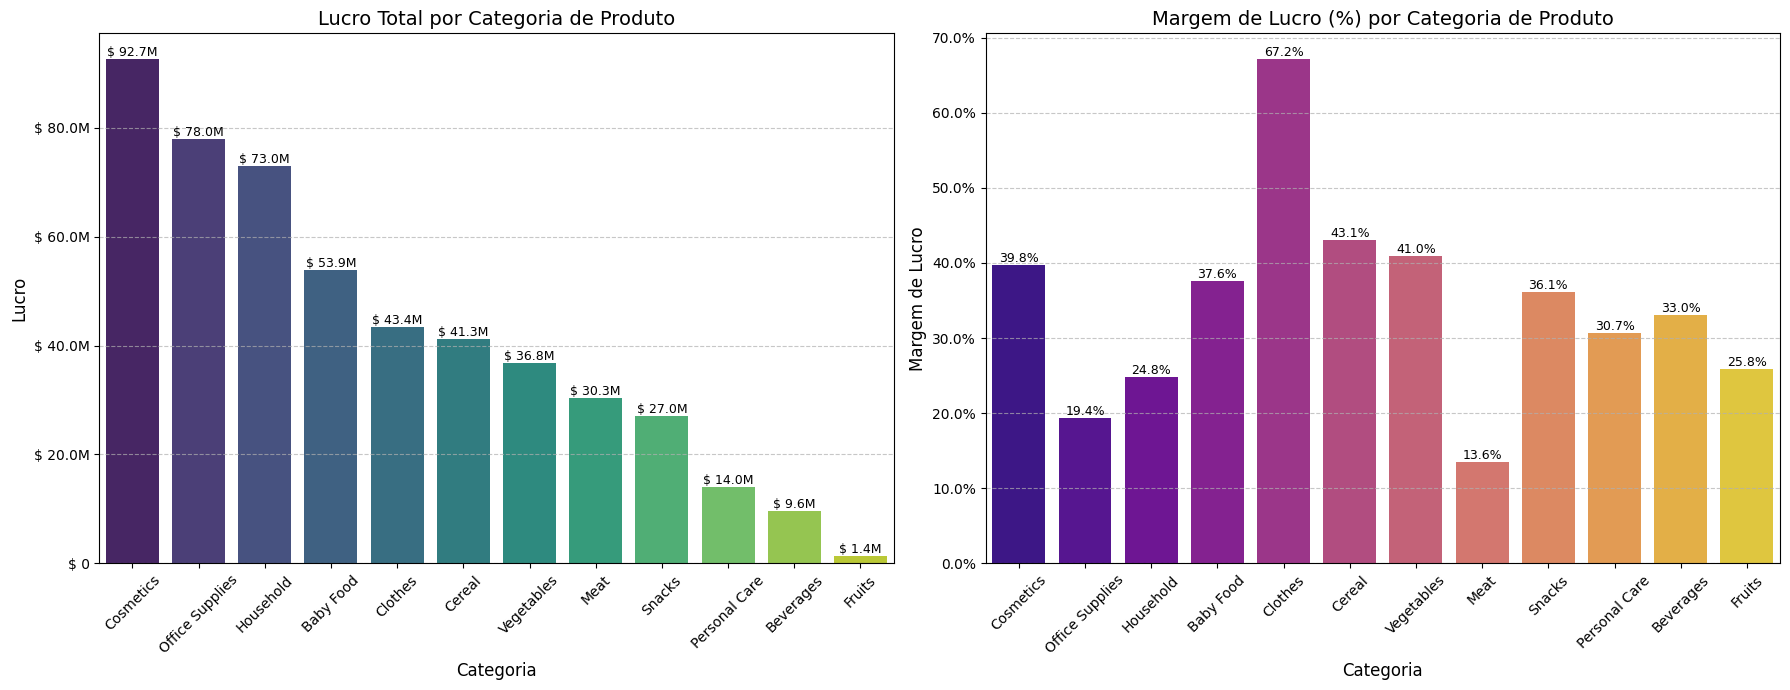

In [41]:
df_categoria_sorted = df_categoria.sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_categoria_sorted, x='Product Category', y='Profit', ax=axes[0], palette='viridis', hue='Product Category', legend=False)
axes[0].set_title('Lucro Total por Categoria de Produto', fontsize=14)
axes[0].set_xlabel('Categoria', fontsize=12)
axes[0].set_ylabel('Lucro', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt=lambda x: currency_formatter(x, None), fontsize=9)

sns.barplot(data=df_categoria_sorted, x='Product Category', y='Profit Margin (%)', ax=axes[1], palette='plasma', hue='Product Category', legend=False)
axes[1].set_title('Margem de Lucro (%) por Categoria de Produto', fontsize=14)
axes[1].set_xlabel('Categoria', fontsize=12)
axes[1].set_ylabel('Margem de Lucro', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(percent_formatter))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: percent_formatter(x, None), fontsize=9)

plt.tight_layout()
plt.show()

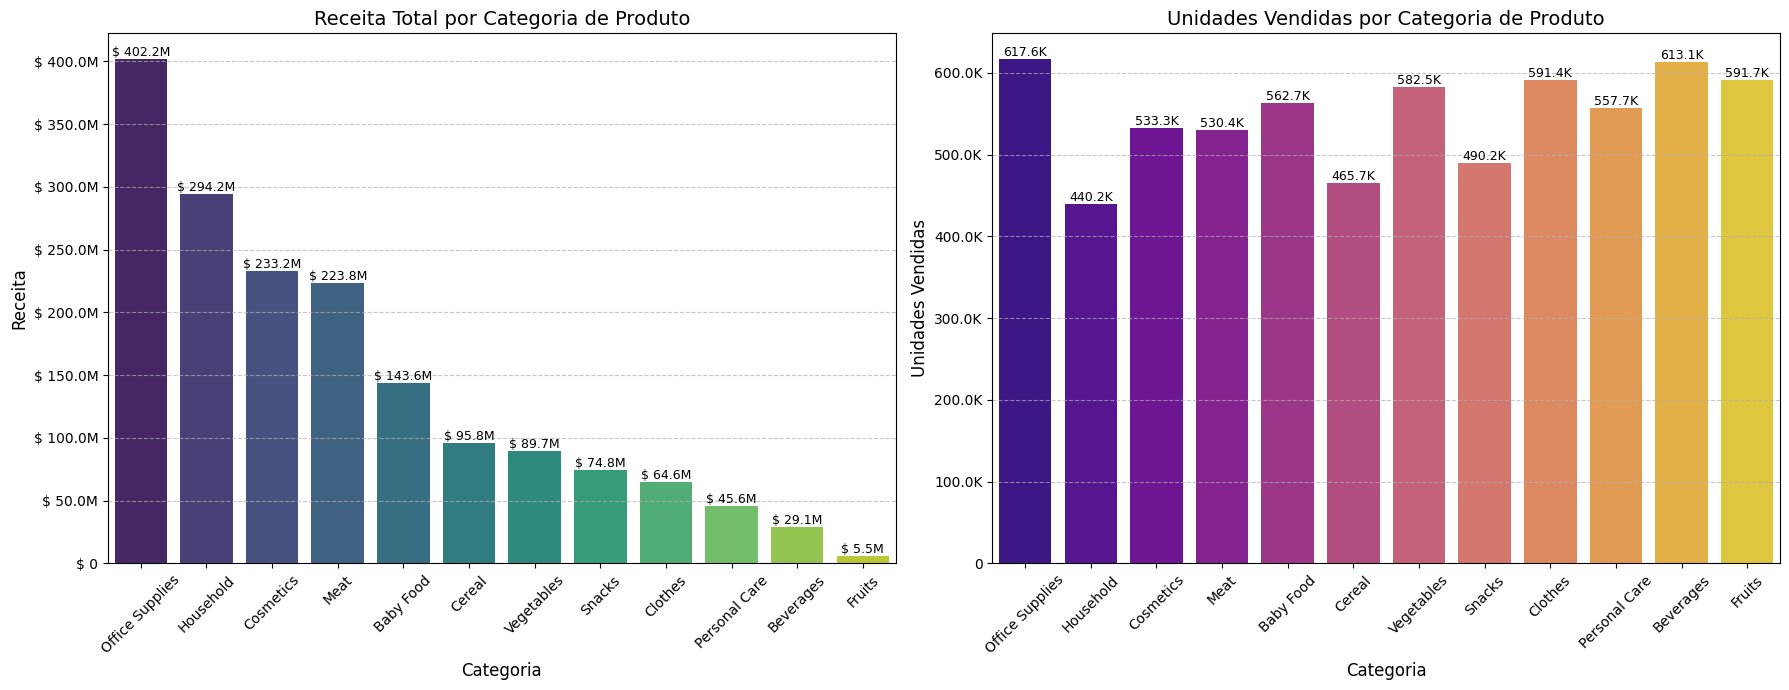

In [42]:
df_categoria_sorted = df_categoria.sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_categoria_sorted, x='Product Category', y='Revenue', ax=axes[0], palette='viridis', hue='Product Category', legend=False)
axes[0].set_title('Receita Total por Categoria de Produto', fontsize=14)
axes[0].set_xlabel('Categoria', fontsize=12)
axes[0].set_ylabel('Receita', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt=lambda x: currency_formatter(x, None), fontsize=9)

sns.barplot(data=df_categoria_sorted, x='Product Category', y='Units Sold', ax=axes[1], palette='plasma', hue='Product Category', legend=False)
axes[1].set_title('Unidades Vendidas por Categoria de Produto', fontsize=14)
axes[1].set_xlabel('Categoria', fontsize=12)
axes[1].set_ylabel('Unidades Vendidas', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(units_formatter))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: units_formatter(x, None), fontsize=9)

plt.tight_layout()
plt.show()

Para tornar os gráficos mais legíveis, formatei os valores dos eixos e rótulos de dados em milhares/milhões (ex: "R$ 1.4M" em vez do valor completo). Para essa formatação específica, utilizei o módulo `matplotlib.ticker` com auxílio de IA generativa para estruturar a função de formatação customizada — uma técnica que ainda não dominava completamente, mas que revisei e validei antes de aplicar.

Ao analisar lucro total e margem de lucro por categoria, observo que **Cosmetics** lidera em lucro absoluto (R\$ 92,7M), mas não apresenta a maior margem (39,8\%) — o que indica que seu resultado é impulsionado principalmente por um volume de receita alto, não por eficiência proporcional. Padrão semelhante aparece em **Office Supplies**, segunda maior em lucro absoluto (R\$ 78,0M), mas com a segunda menor margem entre todas as categorias (19,4\%).

Em contraste, **Clothes** apresenta a maior margem de lucro do portfólio (67,2%), mas ocupa apenas a 5ª posição em lucro absoluto — evidenciando uma categoria proporcionalmente muito eficiente, porém com volume de receita ainda limitado frente ao seu potencial de rentabilidade. Isso sugere uma oportunidade de negócio: caso exista demanda de mercado disponível, investir no crescimento de vendas de Clothes tende a converter-se em lucro de forma mais eficiente do que em categorias de margem mais baixa.

A análise de receita e unidades vendidas reforça essa leitura. Clothes vendeu 591,4 mil unidades — acima da média das categorias (~548 mil) — mas ocupa apenas a 9ª posição em receita total (R\$ 64,6M). Isso indica que o preço unitário médio da categoria é relativamente baixo, e que aumentar a margem já alta ainda dependeria de crescimento de volume ou de estratégia de precificação para elevar a receita por unidade.

**Office Supplies**, por sua vez, é a categoria com maior receita (R\$ 402,2M) e também a mais vendida em unidades (617,6 mil) — o que justifica seu lucro absoluto elevado mesmo com margem baixa: o volume de vendas compensa a menor eficiência por unidade.

In [43]:
# analise de  receita, custo, lucro, unidades vendidas e margem dos top 10 países de country
df_country = df_final.groupby('Country').agg({
    'Revenue': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).reset_index()
df_country['Profit Margin (%)'] = (df_country['Profit'] / df_country['Revenue']) * 100
df_country_ranked = df_country[df_country['Country'] != 'Unknown'].sort_values('Profit', ascending=False).head(10)
df_country_ranked

,Country,Revenue,Cost,Profit,Units Sold,Profit Margin (%)
1,Andorra,47756693.17,32346656.54,15410036.63,185686,32.267805
43,Ukraine,53252317.54,38447391.80,14804925.74,164577,27.801467
27,Malta,47145320.81,32535192.93,14610127.88,173641,30.989561
36,San Marino,47883708.48,34090715.67,13792992.81,192228,28.805189
18,Hungary,42408249.12,28622018.09,13786231.03,152242,32.508371
26,Macedonia,49222085.25,35537985.30,13684099.95,203078,27.800732
10,Czech Republic,53543932.14,39908338.36,13635593.78,142446,25.466179
35,Russia,46051659.81,32783977.17,13267682.64,165954,28.810433
6,Bosnia and Herzegovina,50117508.49,36859905.72,13257602.77,153545,26.453036
17,Greece,38699541.70,26375091.57,12324450.13,176859,31.846502


In [44]:
# analise de receita, custo, lucro, unidades vendidas e margem por região
df_region = df_final.groupby('Region').agg({
    'Revenue': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).reset_index()
df_region['Profit Margin (%)'] = (df_region['Profit'] / df_region['Revenue']) * 100
df_region.sort_values('Profit', ascending=False)

,Region,Revenue,Cost,Profit,Units Sold,Profit Margin (%)
1,Europe,1.505653e+09,1.057096e+09,4.485568e+08,5761244,29.791514
0,Asia,9.333089e+07,6.817863e+07,2.515225e+07,410427,26.949549


In [45]:
# verificando se
print(df_final[df_final['Country'] != 'Unknown']['Region'].isnull().sum())
print(df_final[df_final['Country'] != 'Unknown']['Country'].nunique())

0
45


Analisei receita, custo, lucro, unidades vendidas e margem de lucro agrupando por país e por região. Antes de comparar os países, removi o grupo `"Unknown"` (82 pedidos sem país identificado) do ranking, para não distorcer a comparação entre países reais — seu total de receita é reportado separadamente.

A análise por região revelou um achado relevante: a operação da empresa está concentrada em apenas **2 regiões geográficas** — Europa e Ásia — confirmando-se que todos os 45 países com vendas registradas (excluindo os registros "Unknown") pertencem a uma dessas duas regiões, sem nenhuma venda registrada nas Américas, África ou Oceania. A Europa domina amplamente a operação, respondendo por R\$ 1,51 bilhão em receita e R\$ 448,6 milhões em lucro (margem de 29,8%), contra R\$ 93,3 milhões em receita e R\$ 25,2 milhões em lucro na Ásia (margem de 26,9%) — a Europa representa, portanto, a grande maioria do negócio tanto em volume quanto em rentabilidade.

Essa concentração geográfica é um ponto relevante do ponto de vista estratégico: a empresa não possui, neste conjunto de dados, presença comercial fora da Europa e Ásia — o que pode indicar tanto uma oportunidade de expansão para novos mercados quanto uma limitação do próprio escopo do dataset analisado.

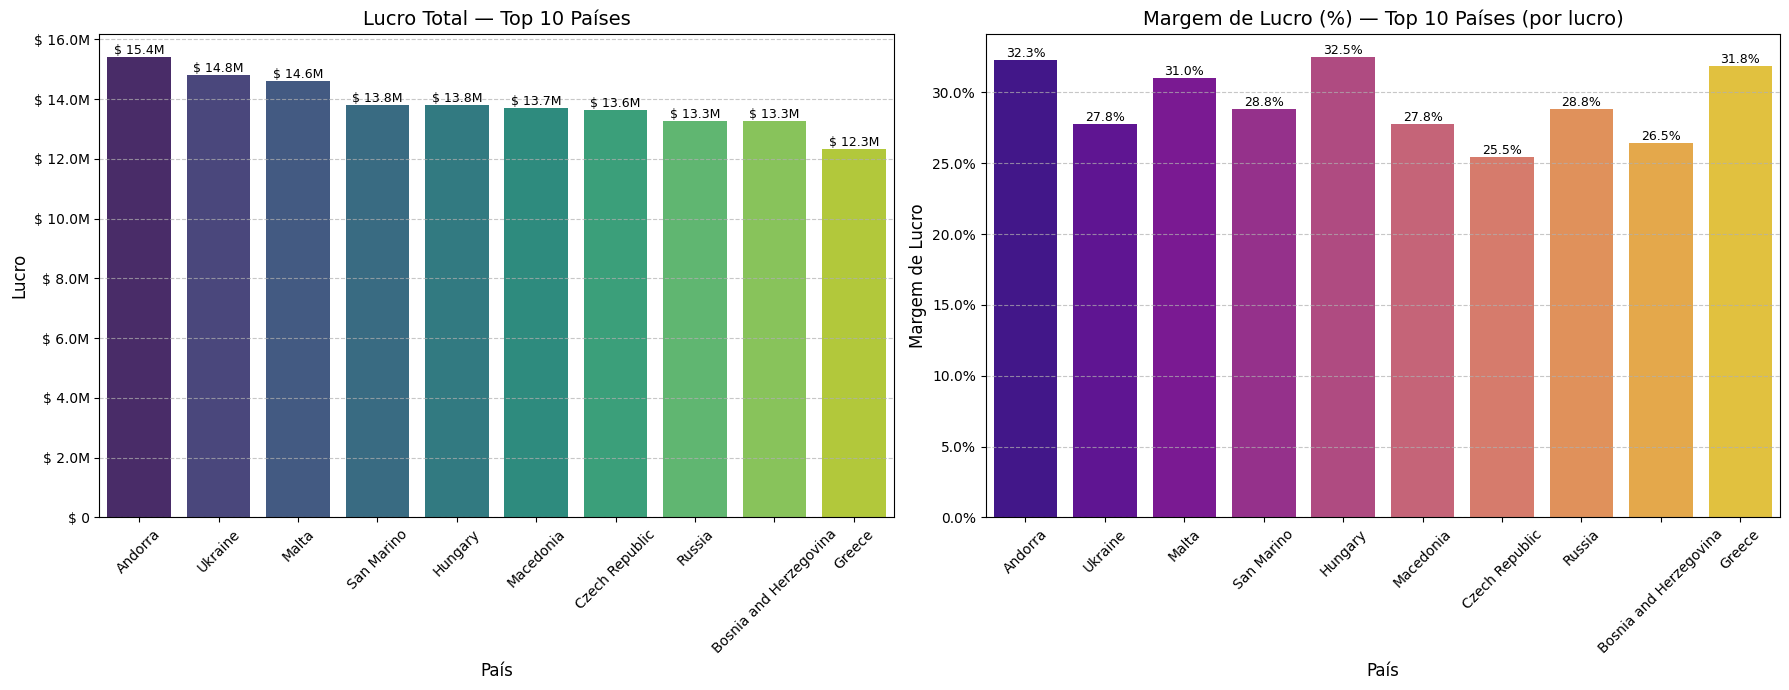

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_country_ranked, x='Country', y='Profit', ax=axes[0], palette='viridis', hue='Country', legend=False)
axes[0].set_title('Lucro Total — Top 10 Países', fontsize=14)
axes[0].set_xlabel('País', fontsize=12)
axes[0].set_ylabel('Lucro', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt=lambda x: currency_formatter(x, None), fontsize=9)

sns.barplot(data=df_country_ranked, x='Country', y='Profit Margin (%)', ax=axes[1], palette='plasma', hue='Country', legend=False)
axes[1].set_title('Margem de Lucro (%) — Top 10 Países (por lucro)', fontsize=14)
axes[1].set_xlabel('País', fontsize=12)
axes[1].set_ylabel('Margem de Lucro', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(percent_formatter))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: percent_formatter(x, None), fontsize=9)

plt.tight_layout()
plt.show()

Entre os 10 países com maior lucro absoluto (excluindo os 82 pedidos sem país identificado), **Andorra** se destaca com o maior lucro (R\$ 15,4M) combinado com uma margem elevada (32,3%). A **Ucrânia** aparece em segundo lugar em lucro (R\$ 14,8M), mas com margem sensivelmente menor (27,8%). **Malta**, em terceiro lugar em lucro (R\$ 14,6M), apresenta margem de 31,0%. Já a **Hungria**, apesar de ocupar apenas a 5ª posição em lucro absoluto (R\$ 13,8M), apresenta a maior margem de todo o grupo (32,5%) — sendo, proporcionalmente, o mercado mais eficiente entre os top 10.

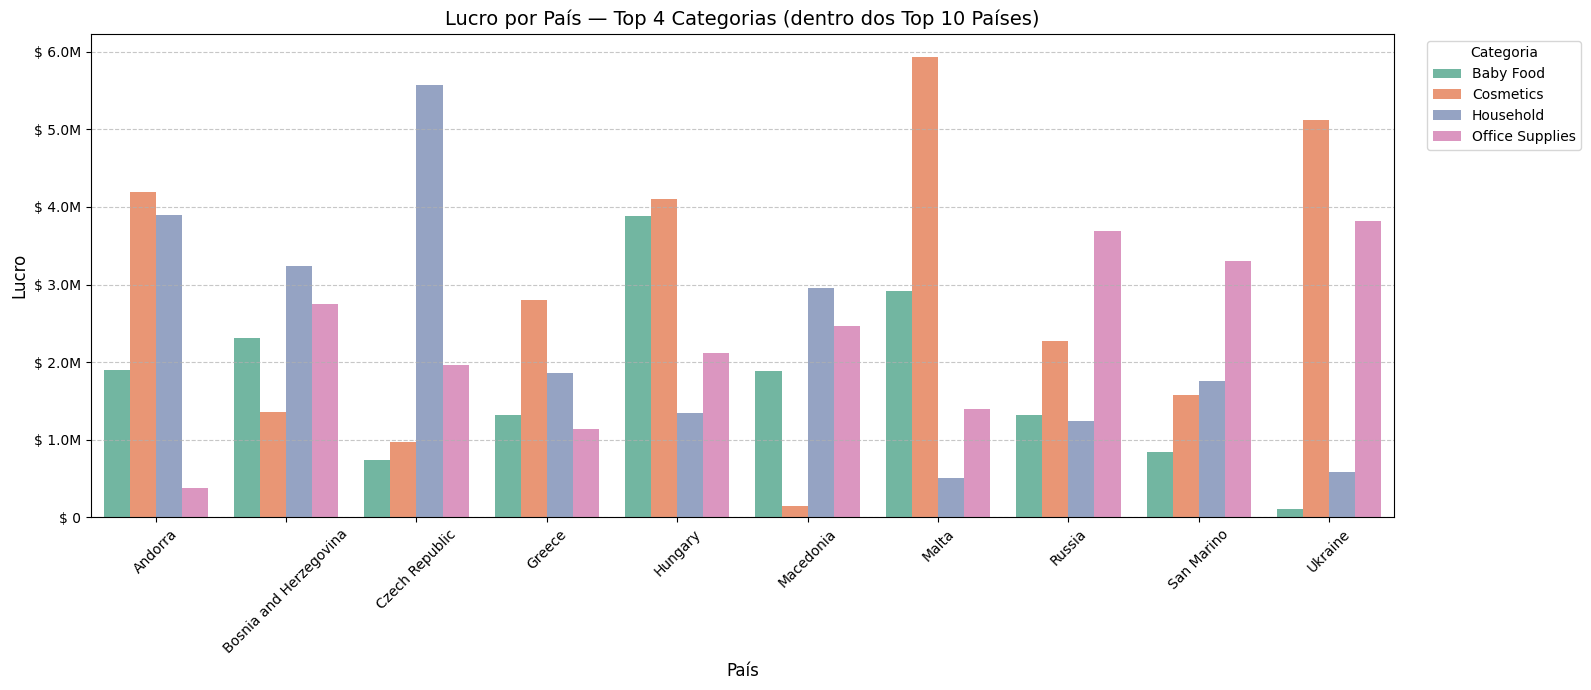

In [47]:
# Top 4 categorias por lucro total (do dataset geral)
top4_categorias = df_categoria.sort_values('Profit', ascending=False).head(4)['Product Category'].tolist()

# Filtrar df_final só para os top 10 países e as top 4 categorias
top10_paises = df_country_ranked['Country'].tolist()
df_filtro = df_final[(df_final['Country'].isin(top10_paises)) & (df_final['Product Category'].isin(top4_categorias))]

# Agrupar por país e categoria
df_pais_categoria = df_filtro.groupby(['Country', 'Product Category']).agg({
    'Profit': 'sum',
    'Units Sold': 'sum'
}).reset_index()

# Gráfico de barras agrupadas
plt.figure(figsize=(16, 7))
sns.barplot(data=df_pais_categoria, x='Country', y='Profit', hue='Product Category', palette='Set2')
plt.title('Lucro por País — Top 4 Categorias (dentro dos Top 10 Países)', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Lucro', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Para investigar se a diferença de margem entre países se relaciona com a composição de categorias vendidas, cruzei os top 10 países com suas 4 categorias de maior lucro no dataset geral (Cosmetics, Baby Food, Household e Office Supplies).

Em **Andorra**, o país com maior lucro absoluto, **Cosmetics** se destaca como a categoria de maior lucro, seguida de perto por Household — essa forte presença de Cosmetics, categoria de margem relativamente alta (39,8%), ajuda a explicar tanto o lucro elevado quanto a boa margem do país (32,3%).

Já na **Bósnia e Herzegovina**, o padrão é diferente: **Household** e **Office Supplies** se destacam como as categorias de maior lucro, com Cosmetics tendo participação bem menor. Como essas duas categorias têm margens mais moderadas (24,8% e 19,4%, respectivamente), isso é consistente com a margem intermediária observada no país (28,8%).

Na **República Checa**, esse padrão fica ainda mais evidente: **Household** domina isoladamente o lucro do país, muito à frente das demais categorias — e a República Checa apresenta a menor margem entre os top 10 países (25,5%), reforçando a relação entre dependência de categorias de margem mais baixa e menor rentabilidade proporcional.

Esse cruzamento sugere que a rentabilidade de um país não depende apenas do volume vendido, mas da composição das categorias que ali predominam: países com maior presença de Cosmetics tendem a apresentar rentabilidade mais alta, enquanto países cujo lucro é concentrado em Household ou Office Supplies (as categorias de margem mais baixa entre as quatro analisadas) tendem a apresentar margem proporcionalmente menor — mesmo quando o lucro absoluto é relevante, como no caso da própria Bósnia e Herzegovina.

In [48]:
df_canal = df_final.groupby('Sales Channel').agg({
    'Revenue' : 'sum',
    'Cost' : 'sum',
    'Units Sold' : 'sum',
    'Profit' : 'sum'
}).reset_index()
df_canal['Profit Margin (%)'] = (df_canal['Profit'] / df_canal['Revenue']) * 100
df_canal['% Profit from Channel'] = (df_canal['Profit'] / lucro_total) * 100
df_canal.sort_values('Profit', ascending=False)
df_canal

,Sales Channel,Revenue,Cost,Units Sold,Profit,Profit Margin (%),% Profit from Channel
0,Offline,8.717606e+08,6.182941e+08,3320363,2.534665e+08,29.075243,50.548285
1,Online,8.303688e+08,5.824008e+08,3256161,2.479679e+08,29.862387,49.451715


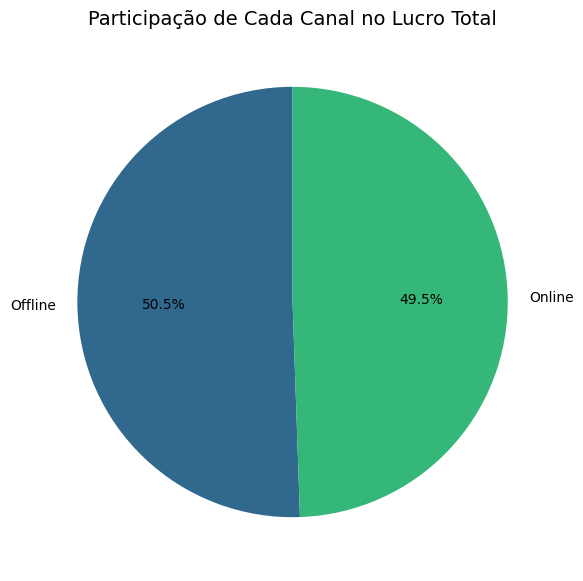

In [49]:
# gráfico de pizza de Sales Channel
plt.figure(figsize=(6, 6))
plt.pie(
    df_canal['Profit'],
    labels=df_canal['Sales Channel'],
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', 2),
    startangle=90
)
plt.title('Participação de Cada Canal no Lucro Total', fontsize=14)
plt.tight_layout()
plt.show()

Analisei receita, custo, lucro, unidades vendidas e margem por canal de vendas (Online vs. Offline). Os dois canais apresentam desempenho bastante equilibrado: **Offline** responde por 50,5% do lucro total da empresa (R$ 253,5M, margem de 29,1%), enquanto **Online** responde por 49,5% (R$ 247,9M, margem de 29,9%). Apesar de o Offline gerar volume de lucro ligeiramente maior, o canal Online apresenta margem um pouco superior — indicando que, embora vendam em proporções semelhantes, o canal Online converte ligeiramente mais receita em lucro proporcionalmente.

In [50]:
df_final['Shipping Time (days)'] = (df_final['Ship Date'] - df_final['Order Date']).dt.days
df_final.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority',
       'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost',
       'Product Category', 'Country', 'Region', 'Sub-Region', 'Revenue',
       'Cost', 'Profit', 'Shipping Time (days)'],
      dtype='object')

In [51]:
df_tempo_categoria = df_final.groupby('Product Category')['Shipping Time (days)'].mean().reset_index()
df_tempo_categoria.sort_values('Shipping Time (days)', ascending=False)

,Product Category,Shipping Time (days)
2,Cereal,27.184466
8,Office Supplies,26.707317
0,Baby Food,26.339286
4,Cosmetics,25.912281
7,Meat,25.909091
10,Snacks,25.543689
5,Fruits,24.419643
1,Beverages,24.123967
6,Household,23.938144
11,Vegetables,23.491228


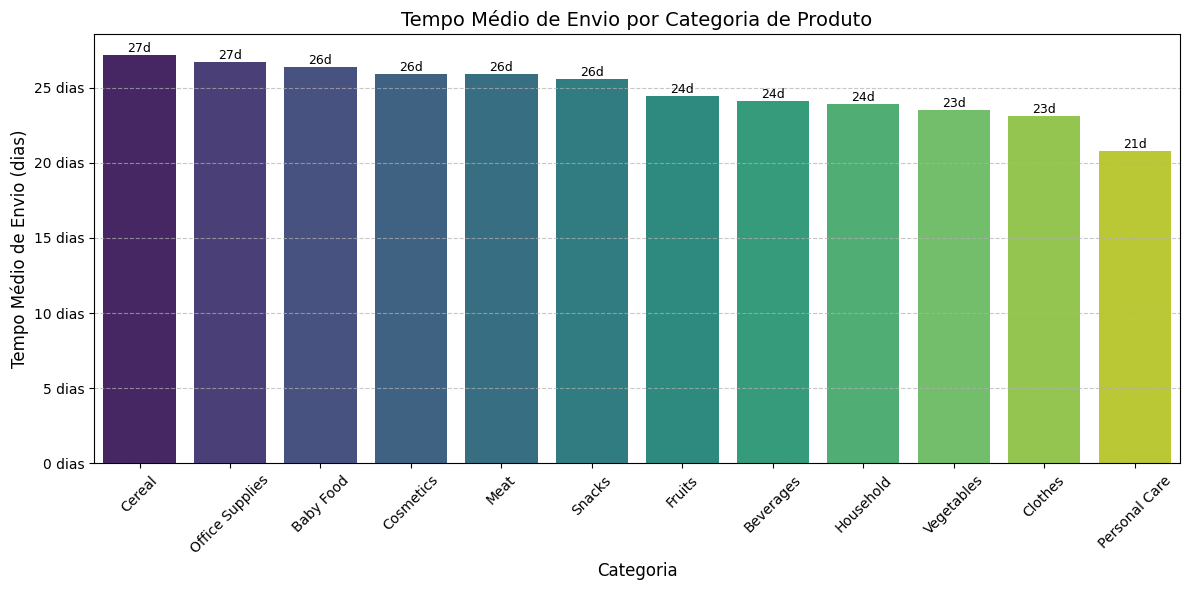

In [52]:
def days_formatter(x, pos):
    return f'{x:.0f} dias'

df_tempo_categoria_sorted = df_tempo_categoria.sort_values('Shipping Time (days)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_tempo_categoria_sorted, x='Product Category', y='Shipping Time (days)', palette='viridis', hue='Product Category', legend=False)
plt.title('Tempo Médio de Envio por Categoria de Produto', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Tempo Médio de Envio (dias)', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(days_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:.0f}d', fontsize=9)

plt.tight_layout()
plt.show()

Analisei o tempo médio de envio (`Ship Date - Order Date`) por categoria de produto. O **Cereal** apresenta o maior tempo médio de envio (27 dias), enquanto **Personal Care** apresenta o menor (21 dias). A diferença entre a categoria mais lenta e a mais rápida é de apenas 6 dias, e a maioria das categorias está concentrada em uma faixa relativamente estreita, entre 23 e 26 dias — não há uma categoria que se destaque isoladamente como excepcionalmente rápida ou lenta em relação às demais.

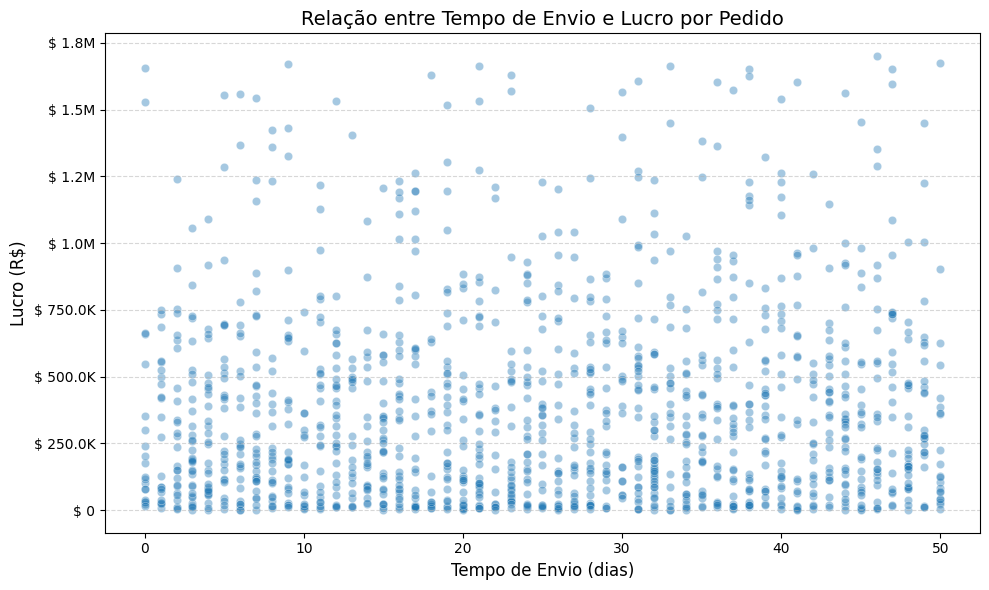

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Shipping Time (days)', y='Profit', alpha=0.4)
plt.title('Relação entre Tempo de Envio e Lucro por Pedido', fontsize=14)
plt.xlabel('Tempo de Envio (dias)', fontsize=12)
plt.ylabel('Lucro (R$)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [54]:
df_final['Shipping Time (days)'].corr(df_final['Profit'])

np.float64(0.06029945527174068)

Investiguei se o lucro de um pedido está relacionado ao tempo necessário para envio (`Ship Date - Order Date`), visualizando a dispersão entre as duas variáveis em um gráfico de pontos e calculando o coeficiente de correlação entre elas.

O gráfico não revela nenhum padrão visual de tendência — pedidos com lucro alto e baixo aparecem distribuídos de forma semelhante em praticamente todas as faixas de tempo de envio, do mais rápido ao mais lento. Essa leitura é confirmada pelo coeficiente de correlação de 0,06 (numa escala de -1 a 1), valor próximo de zero que indica ausência de relação linear relevante entre as duas variáveis.

Conclui-se que o tempo de envio não é um fator determinante para a lucratividade de um pedido nesse conjunto de dados — pedidos lucrativos ocorrem com a mesma frequência independentemente de serem enviados rapidamente ou levarem mais tempo.

In [55]:
# criando colunas de mês e ano
df_final['Order Year'] = df_final['Order Date'].dt.year
df_final['Order Month'] = df_final['Order Date'].dt.to_period('M').astype(str)

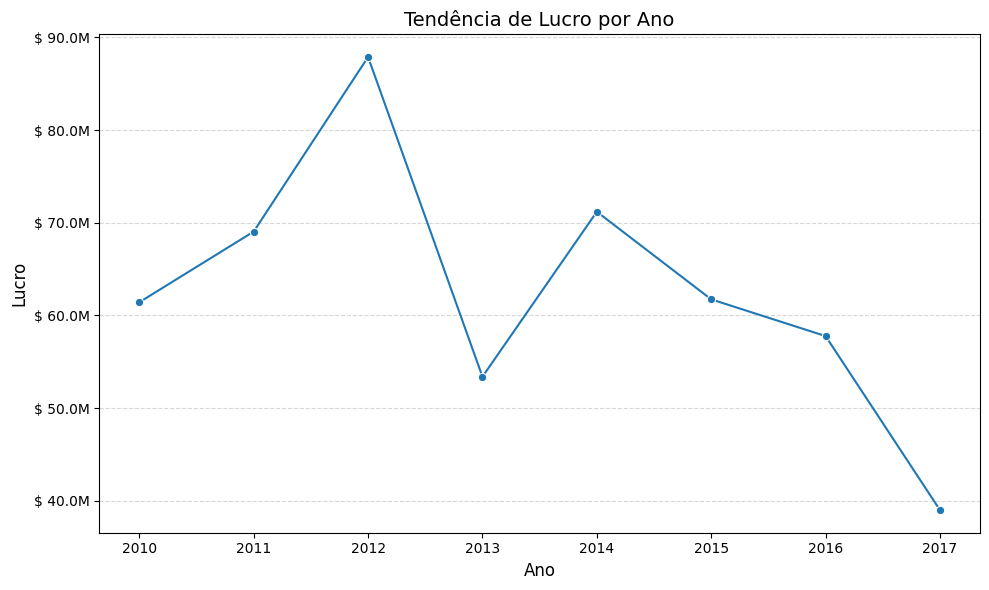

In [56]:
df_ano = df_final.groupby('Order Year')['Profit'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_ano, x='Order Year', y='Profit', marker='o')
plt.title('Tendência de Lucro por Ano', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Lucro', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

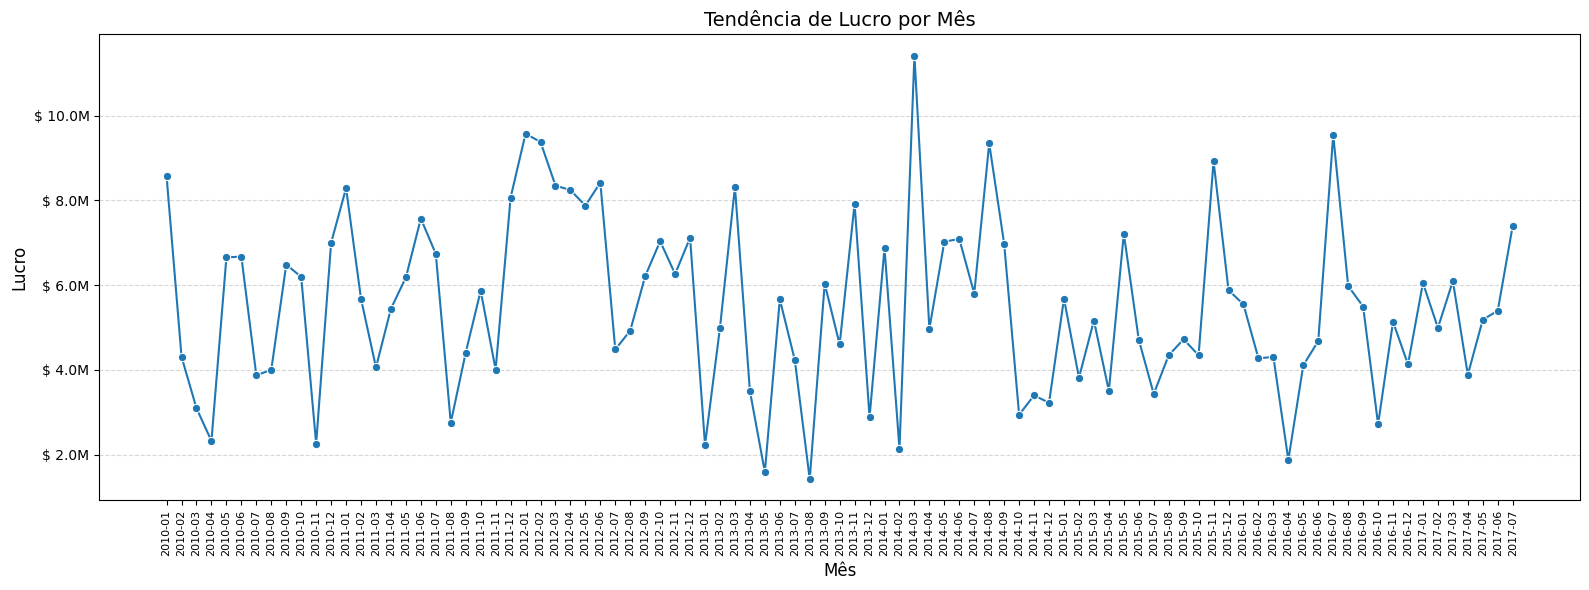

In [57]:
df_mes = df_final.groupby('Order Month')['Profit'].sum().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=df_mes, x='Order Month', y='Profit', marker='o')
plt.title('Tendência de Lucro por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Lucro', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

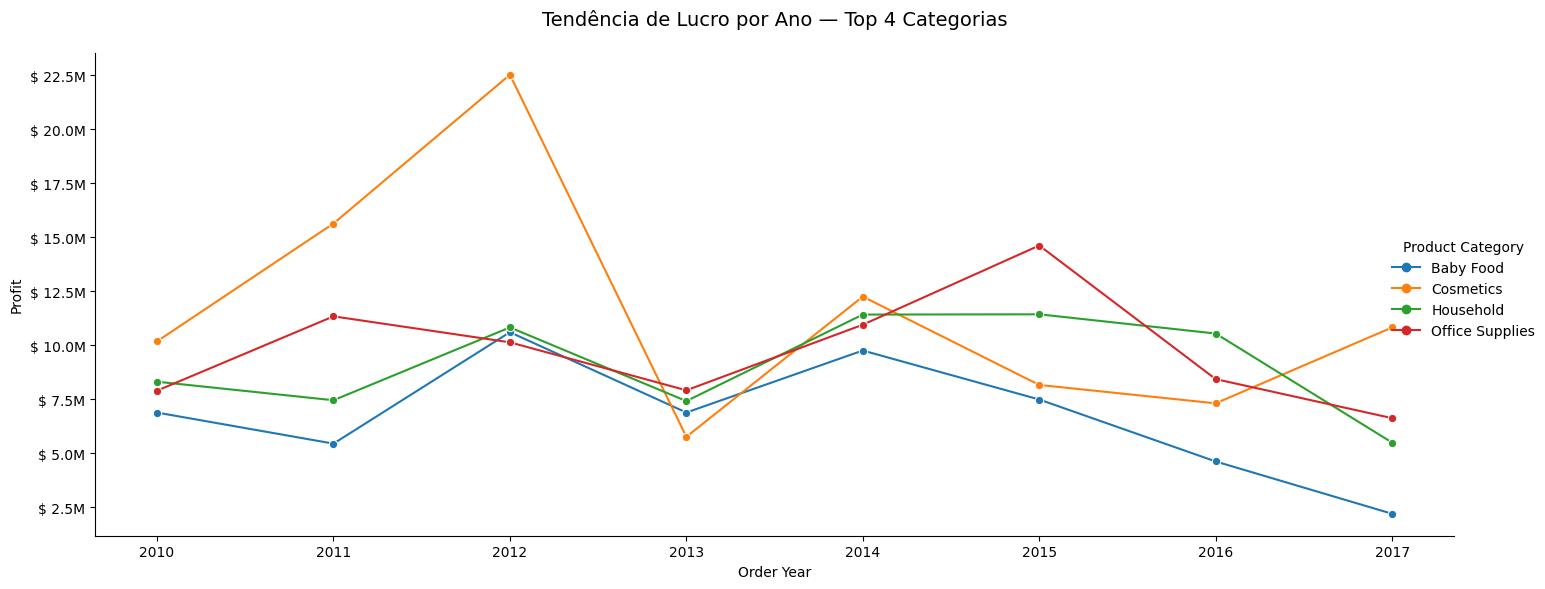

In [58]:
top4_categorias = df_categoria.sort_values('Profit', ascending=False).head(4)['Product Category'].tolist()

df_tendencia_top4 = df_final[df_final['Product Category'].isin(top4_categorias)].groupby(['Order Year', 'Product Category'])['Profit'].sum().reset_index()

g = sns.relplot(
    data=df_tendencia_top4,
    x='Order Year', y='Profit', hue='Product Category',
    kind='line', marker='o', height=6, aspect=2.2
)
g._legend.set_bbox_to_anchor((1.05, 0.5))
g.ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter))
plt.title('Tendência de Lucro por Ano — Top 4 Categorias', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Analisei a evolução do lucro ao longo do tempo em três níveis de granularidade: anual, mensal e anual por categoria.

**Visão anual**: o lucro da empresa não apresenta uma tendência de crescimento ou queda constante ao longo do período — há oscilações acentuadas ano a ano, com um pico em 2012 (R\$ 88,9M) e no gráfico aparece uma queda expressiva em 2017 (R\$ 39,9M, o menor valor do período), porém, devemos tomar cuidado com esse diagnóstico, pois o ano de 2017 está incompleto e vai apenas até julho. Não há um padrão de crescimento sustentado visível na série.

**Visão mensal**: a série mensal confirma a alta volatilidade observada na visão anual, com picos e quedas frequentes mês a mês, sem uma tendência linear clara de longo prazo. Essa oscilação constante sugere que o negócio não segue um padrão sazonal simples e recorrente, mas sim variações mais irregulares ao longo do tempo.

**Visão por categoria (Top 4)**: ao decompor a tendência anual entre as quatro categorias de maior lucro (Cosmetics, Office Supplies, Household e Baby Food), observo que **Cosmetics** foi responsável pelo pico de lucro geral da empresa em 2012, com valor muito acima das demais categorias naquele ano — indicando que o pico geral observado na visão anual foi impulsionado principalmente por essa categoria, não por um crescimento generalizado do negócio. Em 2015, **Office Supplies** assume a liderança entre as categorias, mostrando que a categoria "líder" do ano varia ao longo do tempo, sem uma única categoria dominando de forma consistente todos os períodos.

In [59]:
df_final['Order Day of Week'] = df_final['Order Date'].dt.day_name()
df_dia_semana = df_final.groupby('Order Day of Week')['Units Sold'].sum().reset_index()
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_dia_semana['Order Day of Week'] = pd.Categorical(df_dia_semana['Order Day of Week'], categories=ordem_dias, ordered=True)
df_dia_semana = df_dia_semana.sort_values('Order Day of Week')
df_final

,Order ID,Order Date,Ship Date,Order Priority,Sales Channel,Units Sold,Unit Price,Unit Cost,Product Category,Country,Region,Sub-Region,Revenue,Cost,Profit,Shipping Time (days),Order Year,Order Month,Order Day of Week
0,100640618,2014-10-08,2014-10-18,M,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10,2014,2014-10,Wednesday
1,100983083,2016-08-11,2016-08-11,C,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0,2016,2016-08,Thursday
2,101025998,2014-07-18,2014-08-11,M,Online,4693,668.27,502.54,Household,Unknown,NaN,NaN,3136191.11,2358420.22,777770.89,24,2014,2014-07,Friday
3,102230632,2017-05-13,2017-06-13,L,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31,2017,2017-05,Saturday
4,103435266,2012-08-11,2012-09-18,H,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38,2012,2012-08,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,994504153,2017-01-10,2017-01-13,M,Online,4734,9.33,6.92,Fruits,Sweden,Europe,Northern Europe,44168.22,32759.28,11408.94,3,2017,2017-01,Tuesday
1324,994978797,2014-12-05,2015-01-02,H,Offline,5192,47.45,31.79,Beverages,Italy,Europe,Southern Europe,246360.40,165053.68,81306.72,28,2014,2014-12,Friday
1325,996754205,2010-09-20,2010-09-22,L,Offline,574,255.28,159.42,Baby Food,Russia,Europe,Eastern Europe,146530.72,91507.08,55023.64,2,2010,2010-09,Monday
1326,998043382,2010-06-15,2010-07-03,H,Online,2070,437.20,263.33,Cosmetics,Malta,Europe,Southern Europe,905004.00,545093.10,359910.90,18,2010,2010-06,Tuesday


::

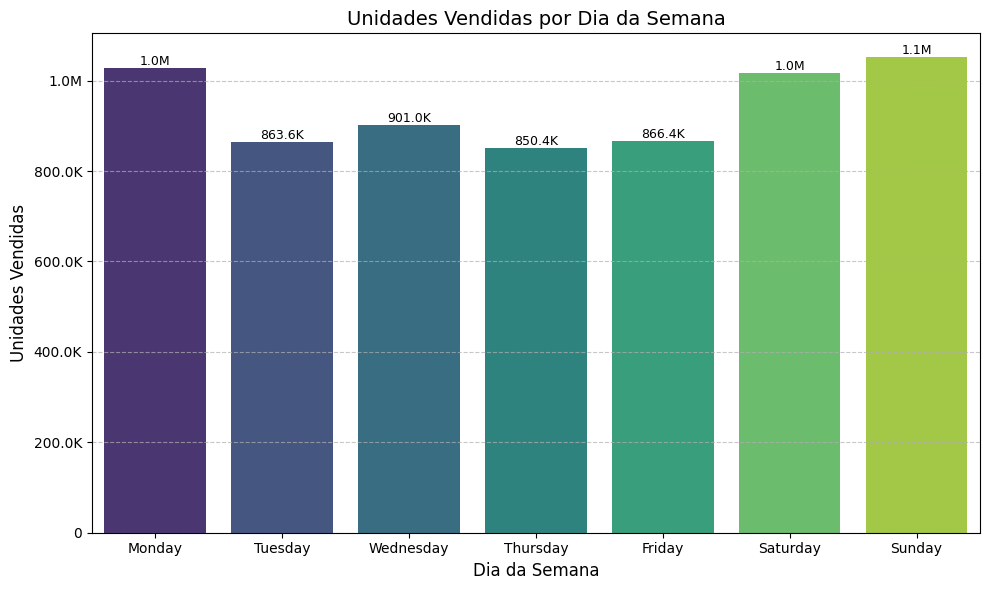

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dia_semana, x='Order Day of Week', y='Units Sold', palette='viridis', hue='Order Day of Week', legend=False)
plt.title('Unidades Vendidas por Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(units_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: units_formatter(x, None), fontsize=9)
plt.tight_layout()
plt.show()

In [61]:
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_dia_categoria = df_final.groupby(['Order Day of Week', 'Product Category'])['Units Sold'].sum().reset_index()
df_dia_categoria['Order Day of Week'] = pd.Categorical(df_dia_categoria['Order Day of Week'], categories=ordem_dias, ordered=True)
df_dia_categoria = df_dia_categoria.sort_values('Order Day of Week')

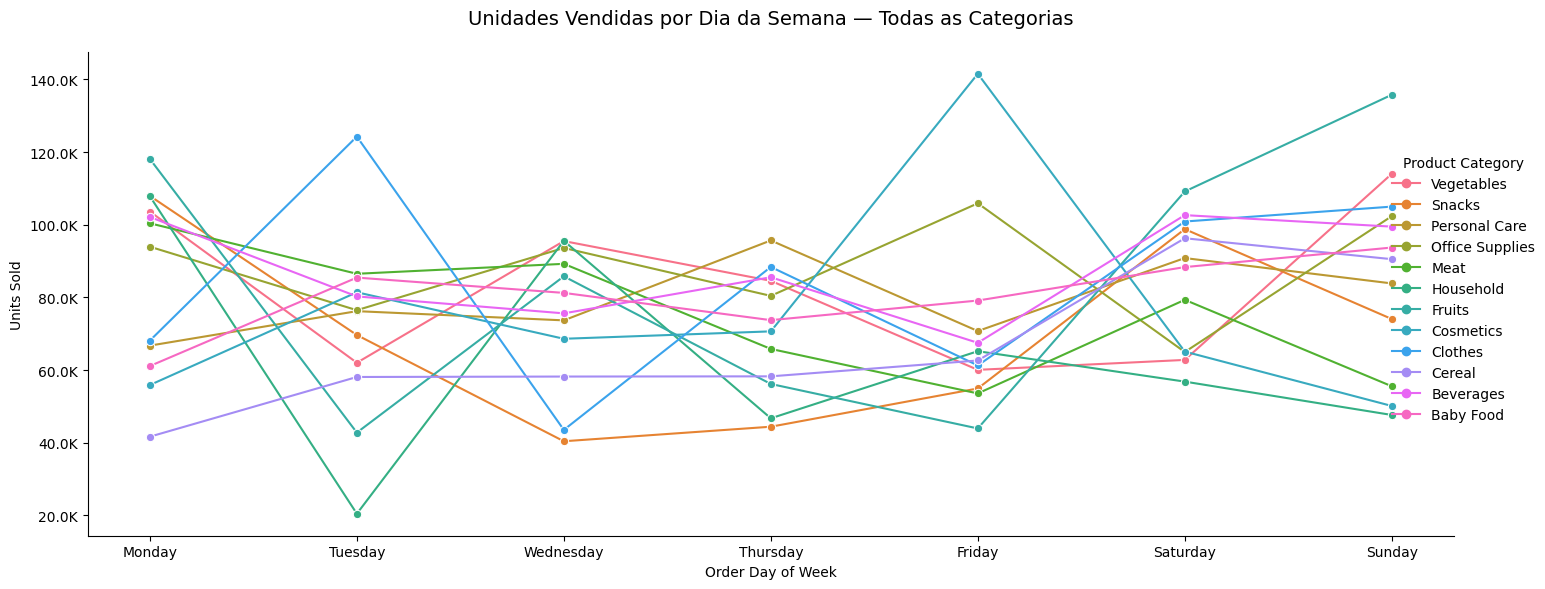

In [62]:
g = sns.relplot(
    data=df_dia_categoria,
    x='Order Day of Week', y='Units Sold', hue='Product Category',
    kind='line', marker='o', height=6, aspect=2.2
)
g._legend.set_bbox_to_anchor((1.05, 0.5))
g.ax.yaxis.set_major_formatter(mticker.FuncFormatter(units_formatter))
plt.title('Unidades Vendidas por Dia da Semana — Todas as Categorias', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

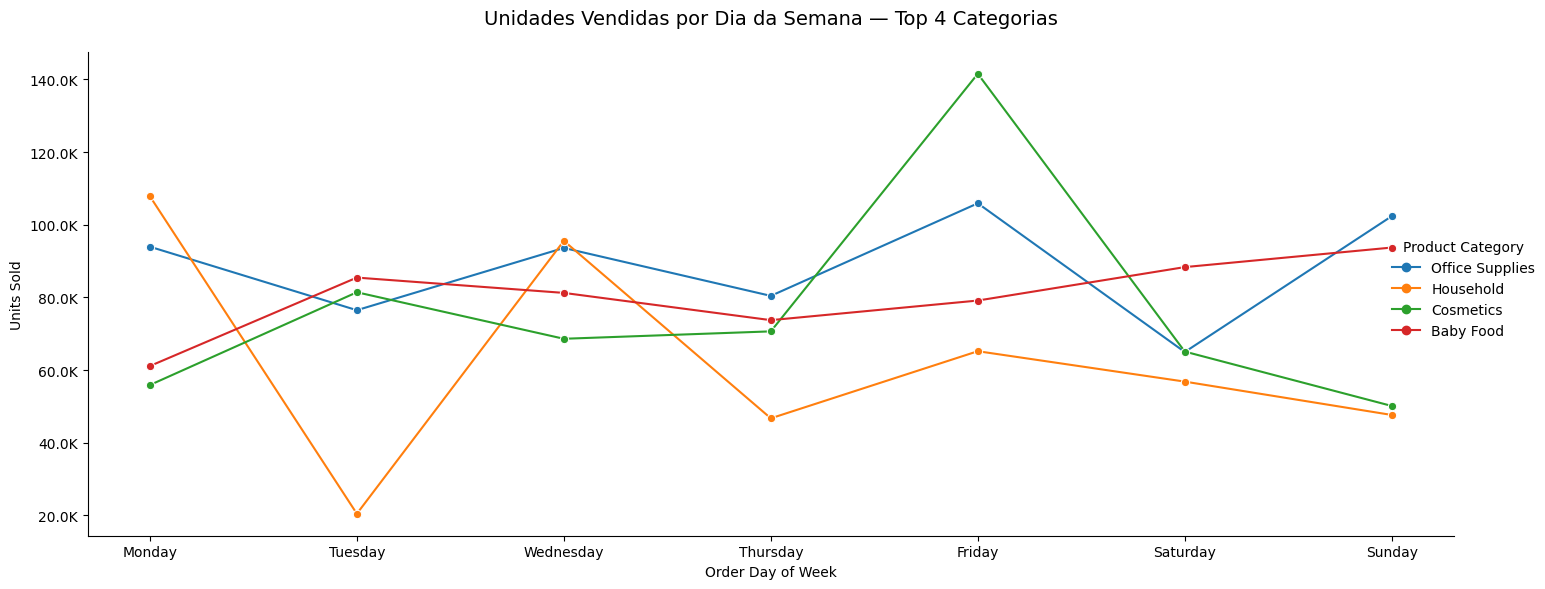

In [63]:
df_dia_top4 = df_dia_categoria[df_dia_categoria['Product Category'].isin(top4_categorias)]

g = sns.relplot(
    data=df_dia_top4,
    x='Order Day of Week', y='Units Sold', hue='Product Category',
    kind='line', marker='o', height=6, aspect=2.2
)
g._legend.set_bbox_to_anchor((1.05, 0.5))
g.ax.yaxis.set_major_formatter(mticker.FuncFormatter(units_formatter))
plt.title('Unidades Vendidas por Dia da Semana — Top 4 Categorias', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

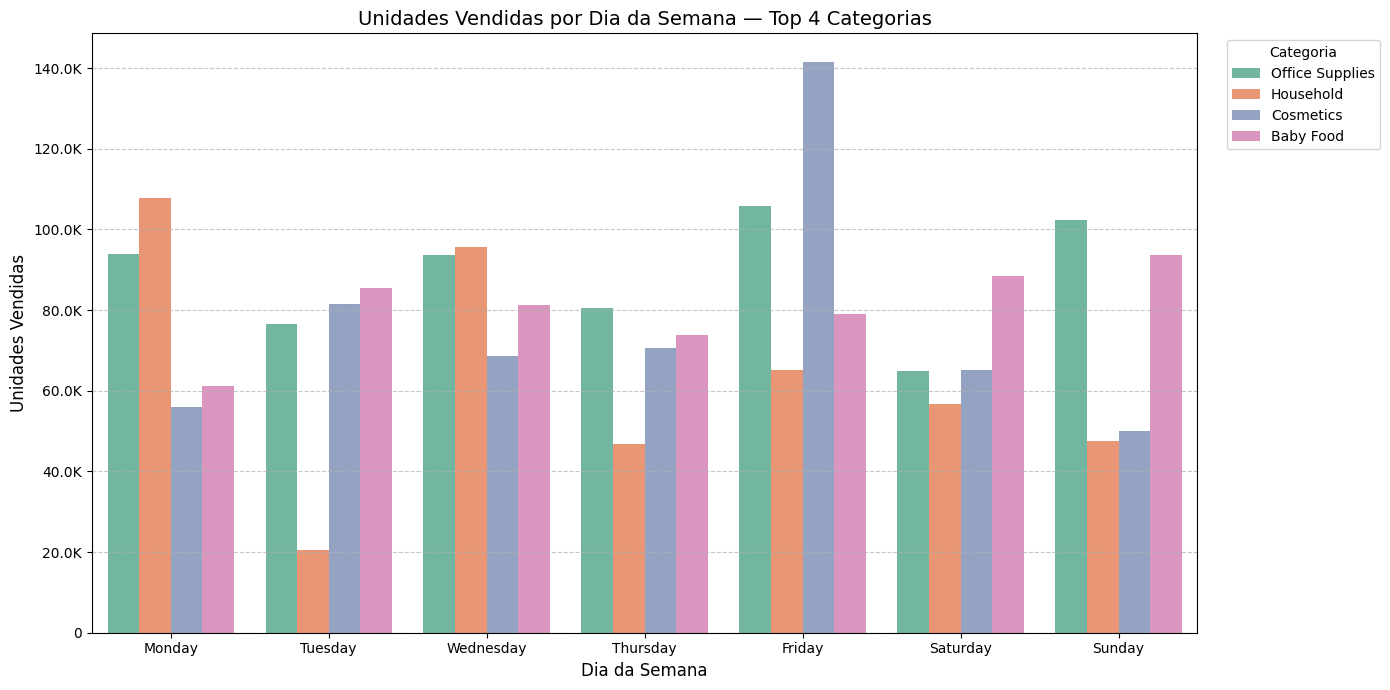

In [64]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_dia_top4, x='Order Day of Week', y='Units Sold', hue='Product Category', palette='Set2')
plt.title('Unidades Vendidas por Dia da Semana — Top 4 Categorias', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(units_formatter))
plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Extraí o dia da semana de `Order Date` (usando `day_name()`) e analisei as unidades vendidas por dia, buscando identificar possíveis padrões de sazonalidade semanal por categoria de produto.

Gerei três visualizações: a primeira incluindo todas as 12 categorias, a segunda e a terceira restritas às 4 categorias de maior lucro (mesma seleção usada nas análises anteriores), em formato de linha e de barras, respectivamente. Com as 12 categorias, o gráfico fica visualmente poluído e dificulta a identificação de padrões — por isso, seguindo a mesma abordagem já usada na análise geográfica e temporal, foquei a leitura de insights nas top 4 categorias (Office Supplies, Household, Cosmetics e Baby Food).

Alguns padrões de sazonalidade semanal ficam evidentes:

- **Household** apresenta uma queda acentuada às terças-feiras, com vendas bem abaixo do padrão observado nos demais dias — o dia de menor volume da categoria na semana toda.
- **Cosmetics** tem seu pico de vendas às sextas-feiras, destacando-se claramente acima das demais categorias nesse dia específico.
- **Baby Food** é a categoria mais estável ao longo da semana, sem grandes picos ou quedas — indicando um padrão de consumo mais constante, pouco sazonal.
- **Office Supplies** mantém-se como uma das categorias mais vendidas na maioria dos dias, com uma leve queda aos sábados.

Esses padrões sugerem que **Household** e **Cosmetics** podem ser consideradas categorias com algum grau de sazonalidade semanal — apresentando dias específicos de pico ou queda —, enquanto **Baby Food** se comporta de forma mais previsível e constante ao longo da semana, sem evidências de sazonalidade relevante.

## Conclusões Finais

A análise do conjunto de dados revela uma operação de médio-grande porte, com 1.328 pedidos, R\$ 1,70 bilhão em receita, R$ 501,4 milhões em lucro (margem de 29,46%) e presença em 46 países.

**Geografia**: a operação está fortemente concentrada em apenas 2 regiões — Europa e Ásia —, sem presença nas Américas, África ou Oceania. A Europa domina o resultado, respondendo pela grande maioria da receita e do lucro. Entre os 10 países com maior lucro, destacam-se Andorra (líder em lucro absoluto e margem elevada), Ucrânia (2º em lucro, porém com margem menor) e Hungria (com maior margem do grupo). Ao cruzar país com categoria, identificamos que a rentabilidade de um país está associada à composição das categorias vendidas ali — mercados com maior presença de Cosmetics tendem a apresentar margens mais altas.

**Categorias de produto**: ao comparar receita e lucro, fica evidente que volume de vendas não é sinônimo de rentabilidade. Office Supplies lidera em receita (R\$ 402,2M), mas apresenta a segunda menor margem entre as categorias (19,4%). Cosmetics, com terceira maior receita (R\$ 233,2M), assume a liderança em lucro absoluto (R$ 92,7M) graças a uma margem consideravelmente mais alta (39,8%). Já Clothes, apesar de ocupar apenas a 5ª posição em lucro absoluto, tem a maior margem do portfólio (67,2%) — uma categoria pequena, porém muito eficiente, que representa oportunidade de crescimento caso exista demanda de mercado disponível.

**Canal de vendas**: Online e Offline apresentam desempenho equilibrado, respondendo por 49,5% e 50,5% do lucro total, respectivamente, com margens muito próximas (29,9% e 29,1%). Não há um canal claramente superior ao outro — a operação está bem distribuída entre os dois.

**Logística e tempo de envio**: o tempo médio de envio varia pouco entre categorias (entre 20 e 27 dias) e não apresenta relação relevante com o lucro do pedido (correlação de apenas 0,06). Isso indica que agilidade de envio não é, neste conjunto de dados, um fator que impacta a rentabilidade — decisões de otimização logística podem focar em outros critérios, como custo operacional, sem preocupação direta com efeito sobre o lucro.

**Dinâmica temporal e sazonalidade**: o lucro da empresa não apresenta uma tendência de crescimento constante ao longo dos 6 anos analisados (2010–2017), com forte oscilação ano a ano. O pico de 2012 foi impulsionado majoritariamente pela categoria Cosmetics, não por um crescimento generalizado do negócio. Na análise semanal, identificamos sazonalidade em categorias específicas — Household apresenta queda acentuada às terças-feiras, e Cosmetics tem pico de vendas às sextas-feiras —, enquanto Baby Food mantém padrão estável ao longo da semana, sem sazonalidade relevante.

### Recomendações de negócio

- **Investir no crescimento de Clothes**: maior margem do portfólio, mas ainda com receita limitada — potencial de lucro incremental eficiente caso haja demanda de mercado.
- **Revisar a estratégia de precificação de Office Supplies**: maior volume de vendas do negócio, mas menor margem — avaliar se há espaço para reprecificação ou renegociação de custos sem comprometer o volume.
- **Avaliar expansão geográfica**: a concentração em apenas 2 regiões (Europa e Ásia) representa tanto uma vulnerabilidade (dependência de poucos mercados) quanto uma oportunidade de expansão para regiões ainda não exploradas.
- **Considerar reforço de estoque sazonal**: categorias com padrão semanal identificado (como Cosmetics às sextas) podem se beneficiar de planejamento de estoque e campanhas alinhadas a esses picos.